In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

### geting the data

In [17]:
data = np.load('train-ubyte.npz')
data

NpzFile 'train-ubyte.npz' with keys: a, b

In [18]:
X = data['a']
Y = data['b']

In [19]:
X = np.reshape(X , (X.shape[0] , -1))
Y = Y + 1

In [22]:
np.random.seed(42)
indices = np.random.choice(X.shape[0] , 10000 , replace=False)
X = X[indices]
Y = Y[indices]

In [23]:
print(X.shape)
print(Y.shape)

(10000, 784)
(10000,)


### section a

In [24]:
pca = PCA()
pca_on_X = pca.fit_transform(X)

eigenvalues = pca.explained_variance_
print('top 20 eigenvalues :' , eigenvalues[:20])


top 20 eigenvalues : [286579.74017948 273856.53805973 159808.49143361 136346.22367541
 104830.84671791 101217.75771146  88125.49899261  82610.8818431
  73066.72338693  66251.38185293  59809.22147537  56388.23304896
  53561.98943765  51417.05990859  46808.10657154  46166.55580696
  45473.54479623  43530.55375109  42950.0161468   42426.53584944]


#### 2D plot

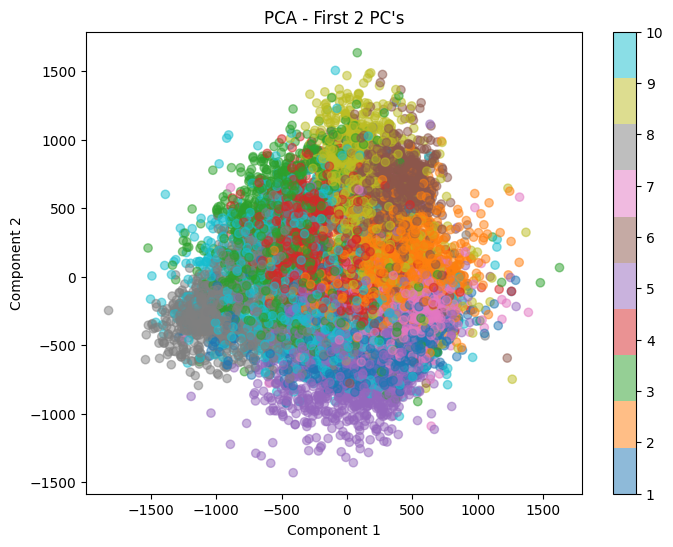

In [37]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_on_X[:, 0], pca_on_X[:, 1], c=Y, cmap='tab10', alpha=0.5)
plt.title('PCA - First 2 PC\'s')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.colorbar(scatter)
plt.show()

#### 3D plot

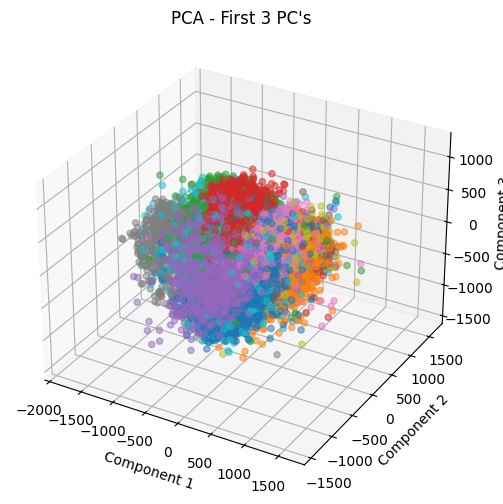

In [38]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_on_X[:, 0], pca_on_X[:, 1], pca_on_X[:, 2], c=Y, cmap='tab10', alpha=0.5)
ax.set_title('PCA - First 3 PC\'s')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
plt.show()

### section b

In [40]:
lda = LDA(n_components=2)
lda_on_X = lda.fit_transform(X, Y)

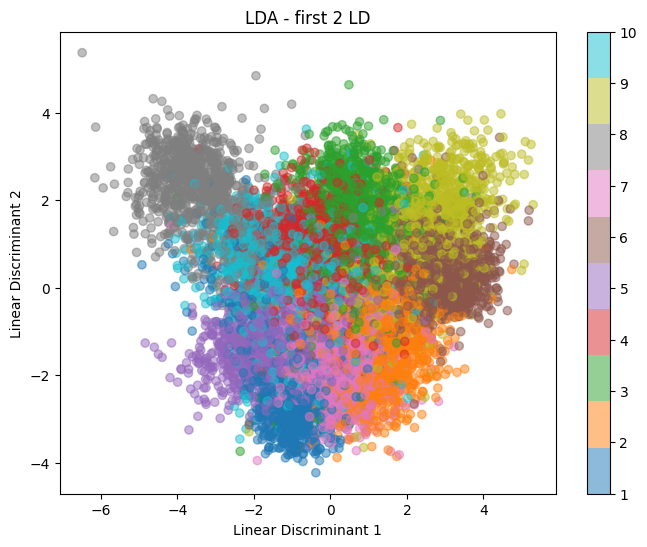

In [41]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(lda_on_X[:, 0], lda_on_X[:, 1], c=Y, cmap='tab10', alpha=0.5)
plt.title('LDA - first 2 LD')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.colorbar(scatter)
plt.show()

### section c

In [42]:
X_2d = pca_on_X[: , :2]
k_vals = [3 , 7 , 10]

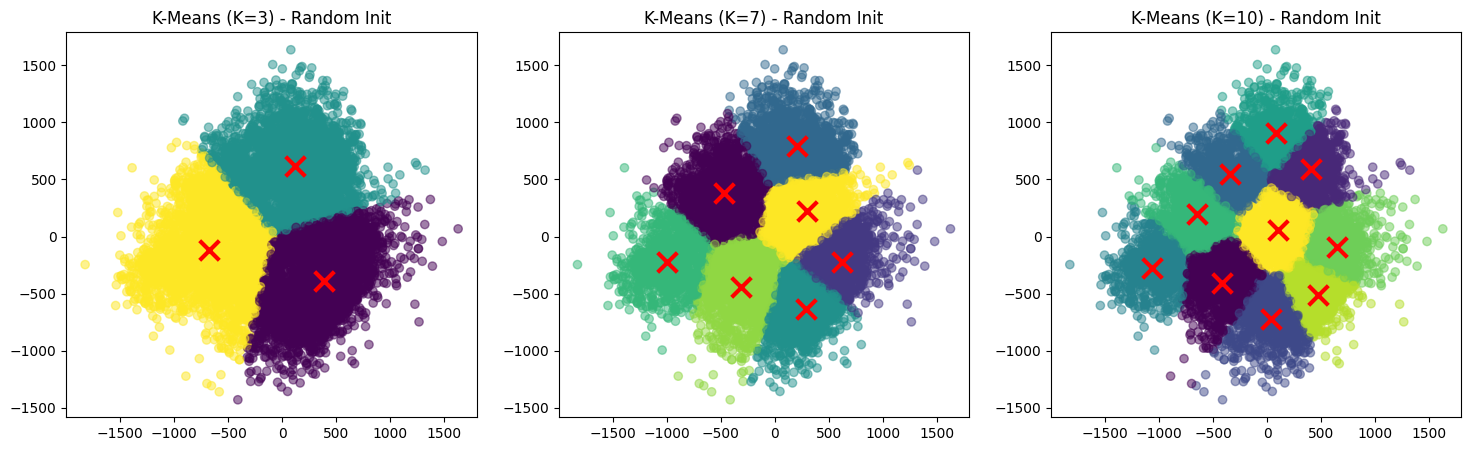

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, k in enumerate(k_vals):
    kmeans = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_2d)
    centers = kmeans.cluster_centers_
    
    axes[i].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', alpha=0.5)
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3)
    axes[i].set_title(f'K-Means (K={k}) - Random Init')

plt.show()

<div dir="rtl" align="right">
در نمودار بخش A مشاهده شد که داده‌های مربوط به ۱۰ کلاس مختلف در فضای دو مؤلفه اصلی (PCA) هم‌پوشانی زیادی دارند و مرز مشخصی بین آن‌ها دیده نمی‌شود. دلیل این موضوع این است که استفاده از فقط دو مؤلفه اصلی، مقدار کمی از واریانس کل تصاویر را نگه می‌دارد و بخش زیادی از اطلاعات از بین می‌رود.

وقتی الگوریتم K-Means را روی این فضای دوبعدی اجرا می‌کنیم، الگوریتم صرفاً فضا را از نظر ریاضی به K ناحیه تقسیم می‌کند. اما این نواحی لزوماً با کلاس‌های واقعی داده‌ها (انواع مختلف نقاشی‌ها) مطابقت ندارند.

برای K = 3، تعداد خوشه‌ها کم است و در نتیجه هر خوشه بسیار بزرگ می‌شود. بنابراین هر خوشه شامل ترکیبی از چند کلاس مختلف و نامرتبط خواهد بود.

برای K = 10، با اینکه تعداد خوشه‌ها با تعداد کلاس‌های واقعی برابر است، به دلیل هم‌پوشانی زیاد داده‌ها در فضای دوبعدی، الگوریتم نمی‌تواند کلاس‌ها را به‌درستی از هم جدا کند. در نتیجه، K-Means فقط فضا را به ۱۰ بخش هندسی تقسیم می‌کند و این تقسیم‌بندی الزاماً با دسته‌بندی واقعی داده‌ها هماهنگ نیست.

</div>

### section d

In [46]:
def get_custom_centroids(classes_list, X_data, y_labels):
    centroids = []
    for cls_group in classes_list:
        mask = np.isin(y_labels, cls_group)
        centroid = X_data[mask].mean(axis=0)
        centroids.append(centroid)
    return np.array(centroids)


centroids_3 = get_custom_centroids([[1,3,5,7], [2,4], [6,8,9,10]], X_2d, Y)
kmeans_3 = KMeans(n_clusters=3, init=centroids_3, n_init=1).fit(X_2d)


centroids_7 = get_custom_centroids([[1,2,5], [3], [4], [6], [7], [9], [8,10]], X_2d, Y)
kmeans_7 = KMeans(n_clusters=7, init=centroids_7, n_init=1).fit(X_2d)


centroids_10 = get_custom_centroids([[i] for i in range(1, 11)], X_2d, Y)
kmeans_10 = KMeans(n_clusters=10, init=centroids_10, n_init=1).fit(X_2d)



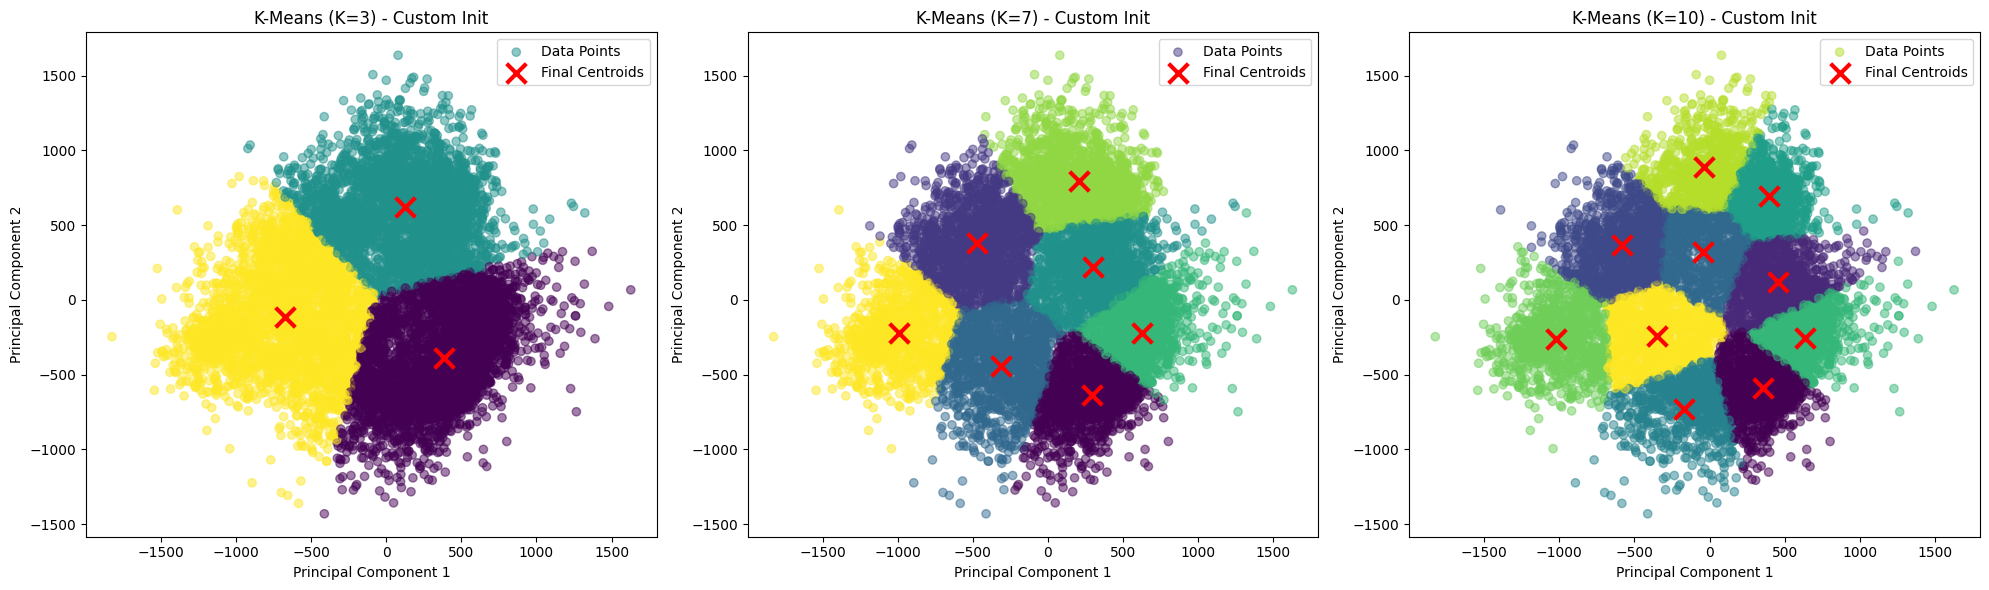

In [47]:
models = [
    (kmeans_3, 3),
    (kmeans_7, 7),
    (kmeans_10, 10)
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (model, k) in enumerate(models):
    labels = model.labels_
    centers = model.cluster_centers_

    axes[i].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', alpha=0.5, label='Data Points')
    
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3, label='Final Centroids')
    
    axes[i].set_title(f'K-Means (K={k}) - Custom Init')
    axes[i].set_xlabel('Principal Component 1')
    axes[i].set_ylabel('Principal Component 2')
    axes[i].legend()

plt.tight_layout()
plt.show()


<div dir="rtl" align="right">
در بخش C، مراکز اولیه به‌صورت کاملاً تصادفی انتخاب شدند؛ بنابراین ممکن است الگوریتم در کمینه‌های محلی گیر کند یا برای همگرا شدن زمان بیشتری نیاز داشته باشد. اما در این بخش، با قرار دادن مراکز اولیه روی میانگین کلاس‌های واقعی، نوعی «دانش قبلی» به الگوریتم داده‌ایم.

در نتیجه مشاهده می‌شود که مراکز خوشه‌ها از همان ابتدا در موقعیت‌های منطقی‌تری نسبت به توزیع داده‌ها قرار دارند. این موضوع کمک می‌کند که نتیجه نهایی خوشه‌بندی تا حد ممکن به ساختار واقعی داده‌ها نزدیک شود، به‌ویژه در حالت‌های K=3 و K=7 که در آن‌ها کلاس‌های مشابه در یک خوشه قرار داده شده‌اند.

با این حال، مشکل اصلی همچنان باقی است؛ یعنی استفاده از تنها دو ویژگی (کاهش شدید بُعد داده‌ها). به همین دلیل نمی‌توان انتظار داشت که جداسازی کاملاً دقیق و بدون خطا انجام شود.
</div>


### section e

In [54]:
pca_95 = PCA(n_components=0.95)
pca_on_X_95 = pca_95.fit_transform(X)
X_rc = pca_95.inverse_transform(pca_on_X_95)

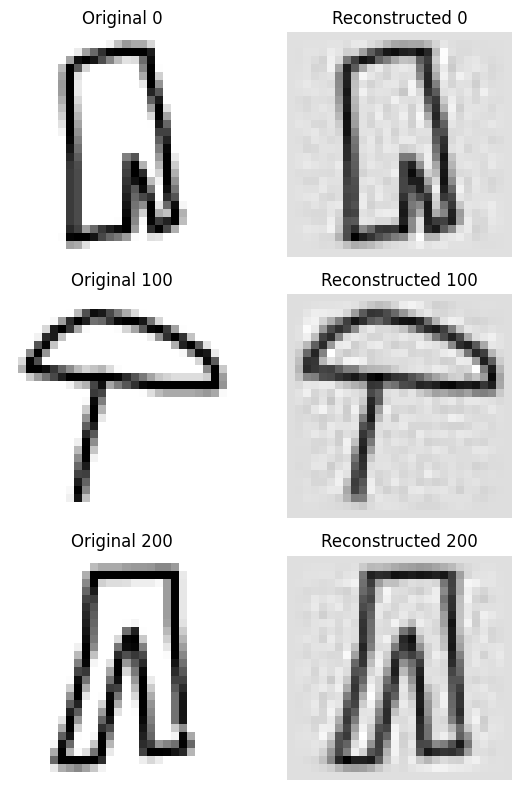

In [57]:
sample_indices = [0, 100, 200] 
fig, axes = plt.subplots(3, 2, figsize=(6, 8))
for i, idx in enumerate(sample_indices):
    orig_img = X[idx].reshape(28, 28) 
    recon_img = X_rc[idx].reshape(28, 28)
    
    axes[i, 0].imshow(orig_img, cmap='gray')
    axes[i, 0].set_title(f'Original {idx}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(recon_img, cmap='gray')
    axes[i, 1].set_title(f'Reconstructed {idx}')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">
برای حفظ ۹۵٪ از واریانس داده‌ها، الگوریتم PCA تعداد نسبتاً زیادی از مؤلفه‌های اصلی را انتخاب می‌کند؛ به‌طوری که این تعداد بسیار بیشتر از ۲ یا ۳ مؤلفه است. این موضوع نشان می‌دهد که اطلاعات موجود در تصاویر در ابعاد بالاتر پخش شده‌اند و با تعداد بسیار کمی مؤلفه نمی‌توان بخش عمده اطلاعات را حفظ کرد.

مقایسه تصاویر بازسازی‌شده با تصاویر اصلی:

تصاویر بازسازی‌شده نسبت به تصاویر اصلی کمی محوتر هستند و جزئیات بسیار ریز (مانند خطوط نازک و طرح‌مانند نقاشی‌ها) در آن‌ها تا حدی از بین رفته است. با این حال، شکل کلی و مفهوم اصلی شیء همچنان حفظ شده و به‌راحتی قابل تشخیص است.

این نتیجه نشان می‌دهد که PCA می‌تواند ابعاد داده‌ها را تا حد زیادی کاهش دهد (و در نتیجه حجم محاسبات را کمتر کند) بدون آنکه اطلاعات مهم از بین برود. علاوه بر این، PCA تا حدی مانند یک فیلتر کاهش نویز نیز عمل می‌کند.

</div>


### section f

In [60]:
kmeans_10_f = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans_10_f.fit_predict(pca_on_X_95)

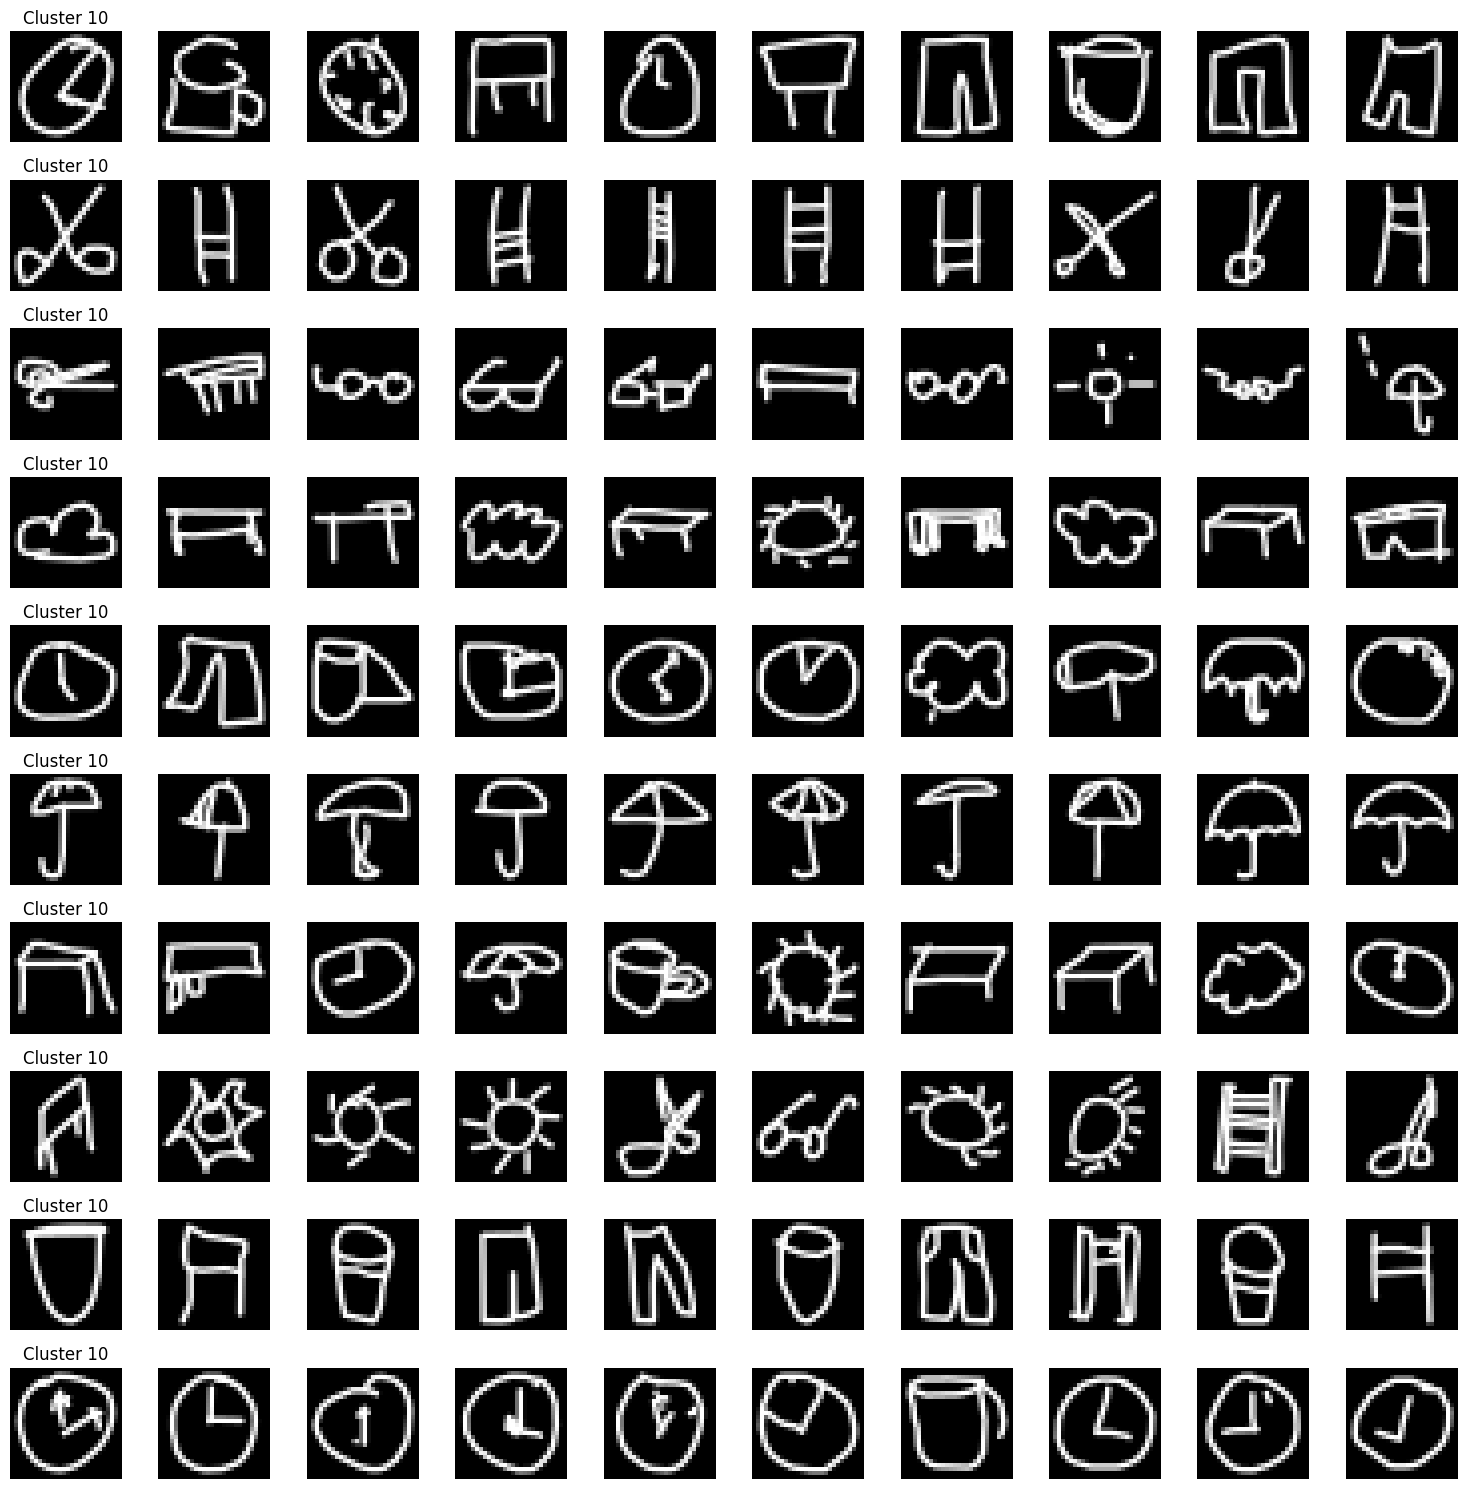

In [70]:
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for cluster_index in range(10):
   
    cluster_indices = np.where(cluster_labels == cluster_index)[0]
    
    if len(cluster_indices) >= 10:
        sampled_indices = np.random.choice(cluster_indices, 10, replace=False)
    else:
        sampled_indices = cluster_indices
        
    for j, img_idx in enumerate(sampled_indices):
        
        axes[cluster_index, j].imshow(X[img_idx].reshape(28, 28), cmap='gray_r')
        axes[cluster_index, j].axis('off')
        
        if j == 0:
            axes[cluster_index, j].set_title(f'Cluster {cluster_idx + 1}')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">
برخلاف بخش c که در آن از فقط ۲ مؤلفه اصلی استفاده شد، در این بخش الگوریتم K-Means روی داده‌هایی اجرا شده است که ۹۵٪ واریانس داده‌ها را حفظ می‌کنند. به همین دلیل خوشه‌ها از نظر معنایی خالص‌تر هستند.

با بررسی ۱۰ تصویر مربوط به هر خوشه مشاهده می‌شود که اشیایی با ویژگی‌های هندسی مشابه بیشتر در کنار هم قرار گرفته‌اند. برای مثال، اشیای دایره‌ای شکل مانند خورشید و ساعت، یا اشیایی با ساختارهای خطی، بیشتر در یک خوشه دیده می‌شوند. افزایش تعداد ابعاد (مؤلفه‌های اصلی) باعث شده است که الگوریتم K-Means بتواند فاصله‌ها و تفاوت‌های واقعی بین تصاویر را بهتر تشخیص دهد.

</div>


### section g

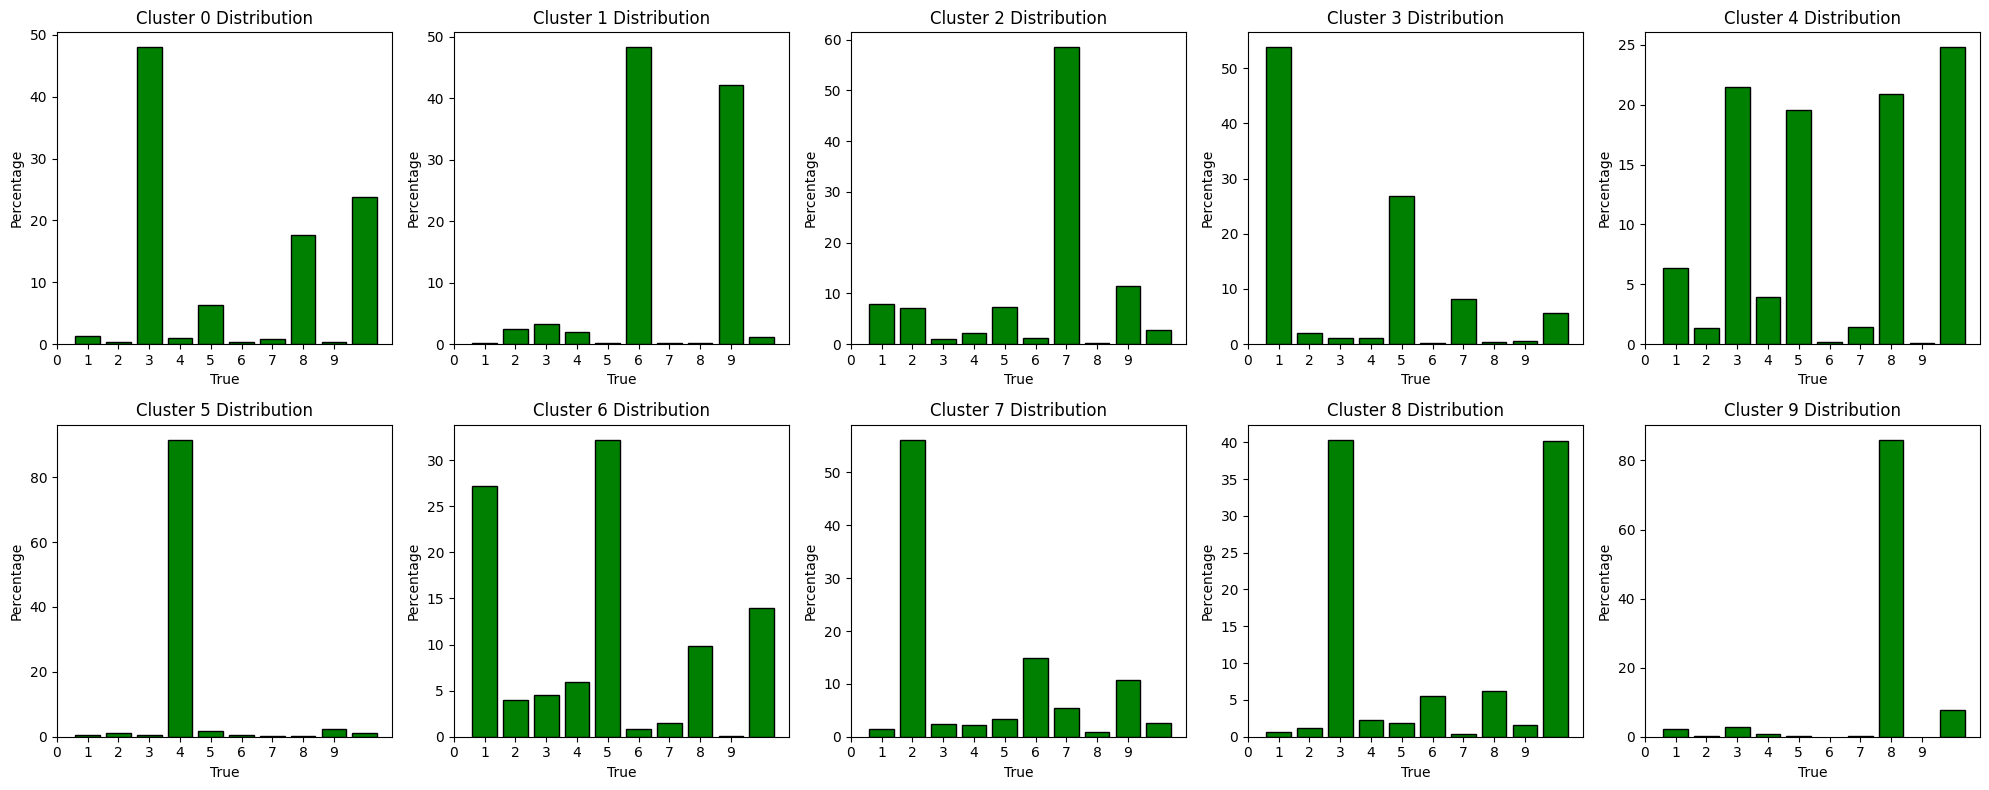

In [71]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for cluster_index in range(10):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]
    true_labels = Y[cluster_indices]
    
    unique_classes, counts = np.unique(true_labels, return_counts=True)
    percentages = (counts / len(true_labels)) * 100
    
    axes[cluster_index].bar(unique_classes, percentages, color='green', edgecolor='black')
    axes[cluster_index].set_title(f'Cluster {cluster_index} Distribution')
    axes[cluster_index].set_xlabel('True')
    axes[cluster_index].set_ylabel('Percentage')
    axes[cluster_index].set_xticks(range(10)) 

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">
یک خوشه ایده‌آل خوشه‌ای است که در نمودار میله‌ای آن فقط یک میله (مربوط به یک کلاس خاص) مقدار زیادی داشته باشد و سایر میله‌ها نزدیک به صفر باشند.

در نمودارهای رسم‌شده مشاهده می‌شود که برخی خوشه‌ها خلوص بالایی دارند؛ برای مثال در یک خوشه حدود ۸۰٪ از اعضا مربوط به یک شیء خاص هستند. این موضوع نشان‌دهنده عملکرد مناسب ترکیب PCA و K-Means است.

با این حال، در بعضی خوشه‌ها ۲ یا ۳ میله ارتفاع تقریباً مشابهی دارند. این مسئله نشان می‌دهد که برخی کلاس‌ها (نقاشی‌ها) از نظر پیکسلی و ظاهری بسیار شبیه به هم بوده‌اند؛ برای مثال نقاشی سیب و ساعت که هر دو شکل دایره‌ای دارند. در نتیجه الگوریتم K-Means آن‌ها را در یک گروه قرار داده است.
</div>


### section h

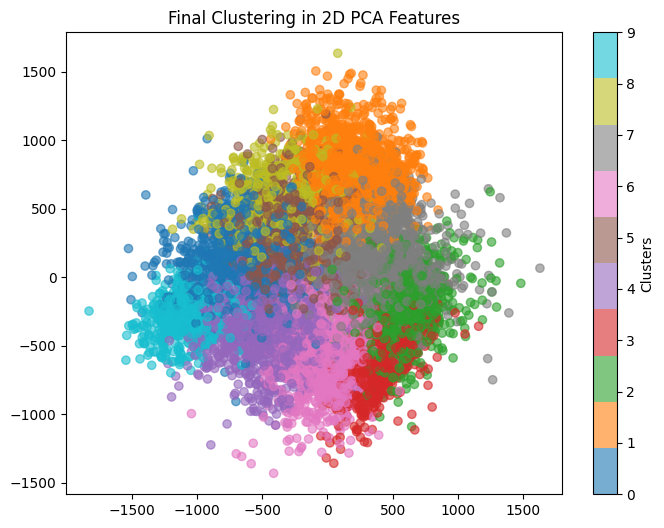

In [72]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_on_X[:, 0], pca_on_X[:, 1], c=cluster_labels,
cmap='tab10', alpha=0.6)
plt.title('Final Clustering in 2D PCA Features')
plt.colorbar(scatter, label='Clusters')
plt.show()

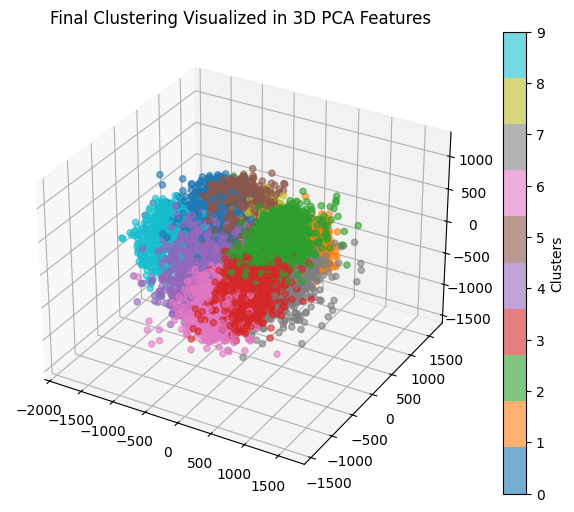

In [73]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter3d = ax.scatter(pca_on_X[:, 0], pca_on_X[:, 1], pca_on_X[:, 2],
c=cluster_labels, cmap='tab10', alpha=0.6)
ax.set_title('Final Clustering Visualized in 3D PCA Features')
plt.colorbar(scatter3d, label='Clusters')
plt.show()